In [1]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
import nilearn
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
# First Level Model - Wang et. al.
from nilearn import masking, plotting
from pathlib import Path
from dotenv import dotenv_values
from nilearn.plotting import plot_design_matrix

In [2]:
# Considerations:
# What HPF
# Lag?
# What model (double gamma)
# read confound files
# spindle files
# which hrf and drift model

In [3]:
# Directories
preproc_ver = 'derivatives'
config = dotenv_values("pipeline_vars.env")
presmooth_file = config.get('smooth_file')
sc_file = config.get('sc_file')
post_sc_file = f'sc{sc_file}_mcf'

SUB = 'sub-AY'
# presmooth_file = f'reg_scRun_BOLD_{SUB}_mcf_unwarp'
DIR = Path('1_directory.txt').read_text().strip()
dir = f'{DIR}{preproc_ver}/{SUB}/preproc/'

anat = f"{dir}/T1/Masked_UNI.nii"

FUNC_IMG = f"{dir}smooth/{presmooth_file}_smooth.nii.gz"
SPINDLE_EV = "/home/asa25/Downloads/spindle_files/C4_spindles_N.txt"
if 'rclean' in presmooth_file:
    CONF_FILE = f"{dir}FIACH/multi_reg_FIACH_6PCs_sub-AY.txt"
    confounds = pd.read_csv(CONF_FILE, sep='\t', header=None)
else:
    CONF_FILE = f"{dir}mc/{post_sc_file}.par"
    confounds = pd.read_csv(CONF_FILE, sep='  ', header=None, engine='python')

print(CONF_FILE)
OUTPUT_DIR = f"/data/Annie/PROJECTS/RM_sleep2024/{preproc_ver}/{SUB}/stats" 

/data/Annie/PROJECTS/RM_sleep2024/derivatives/sub-AY/preproc/mc/scRun_BOLD_sub-AY_mcf.par


In [4]:
spindles = pd.read_csv(SPINDLE_EV, sep=r'\s+', header=None)
spindles.columns = ['onset', 'duration', 'trial_type']
spindles.head()

,onset,duration,trial_type
0,92.668,0.453,1.0
1,97.965,0.570,1.0
2,101.184,0.539,1.0
3,104.848,0.383,1.0
4,106.234,0.422,1.0


In [5]:
print(confounds.dtypes)
confounds

0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
dtype: object


,0,1,2,3,4,5
0,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.000172,0.000263,0.000341,0.003208,-0.022677,0.006030
2,-0.000344,-0.000144,-0.000109,0.000420,0.012307,-0.007817
3,-0.000709,0.000233,0.000382,-0.012647,0.016382,-0.035111
4,0.010088,-0.004338,-0.010506,-0.043294,0.207062,-0.417375
...,...,...,...,...,...,...
125,0.006800,0.003265,0.009700,0.179711,0.326701,0.527476
126,0.006399,0.003922,0.010202,0.180859,0.369438,0.529114
127,0.007775,0.003639,0.010398,0.190137,0.337182,0.448290
128,0.007032,0.002594,0.010803,0.224876,0.352201,0.539024


In [6]:
img = nib.load(FUNC_IMG)
tr = float(img.header.get_zooms()[3]) 
tr

2.5999999046325684

In [7]:
print(spindles.head(2))

    onset  duration  trial_type
0  92.668     0.453         1.0
1  97.965     0.570         1.0


In [8]:
print(spindles.columns.tolist())
print(spindles.dtypes)
print(spindles.shape)

['onset', 'duration', 'trial_type']
onset         float64
duration      float64
trial_type    float64
dtype: object
(41, 3)


In [9]:
n_volumes = 130   # number of volumes in your fMRI run
frame_times = np.arange(n_volumes) * tr

# Extract the three columns from the DataFrame - pack into a tuple
onsets = spindles.iloc[:, 0].values  # first column
durations = spindles.iloc[:, 1].values  # second column
amplitudes = spindles.iloc[:, 2].values  # third column

exp_condition = (onsets, durations, amplitudes)

# Now run compute_regressor
regressor, names = nilearn.glm.first_level.compute_regressor(
    exp_condition,
    hrf_model='glover', # glover, spm (+ derivative + dispersion)
    frame_times=frame_times
)

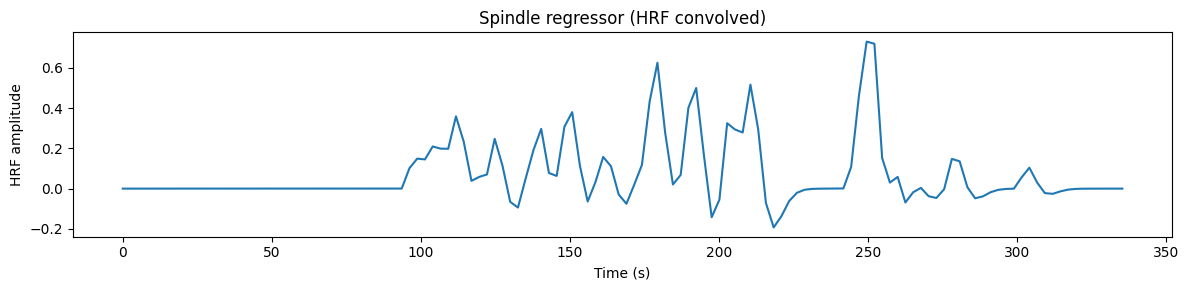

In [10]:
import matplotlib.pyplot as plt

# Quick sanity check — plot the regressor
plt.figure(figsize=(12, 3))
plt.plot(frame_times, regressor[:, 0])
plt.xlabel('Time (s)')
plt.ylabel('HRF amplitude')
plt.title('Spindle regressor (HRF convolved)')
plt.tight_layout()
plt.show()

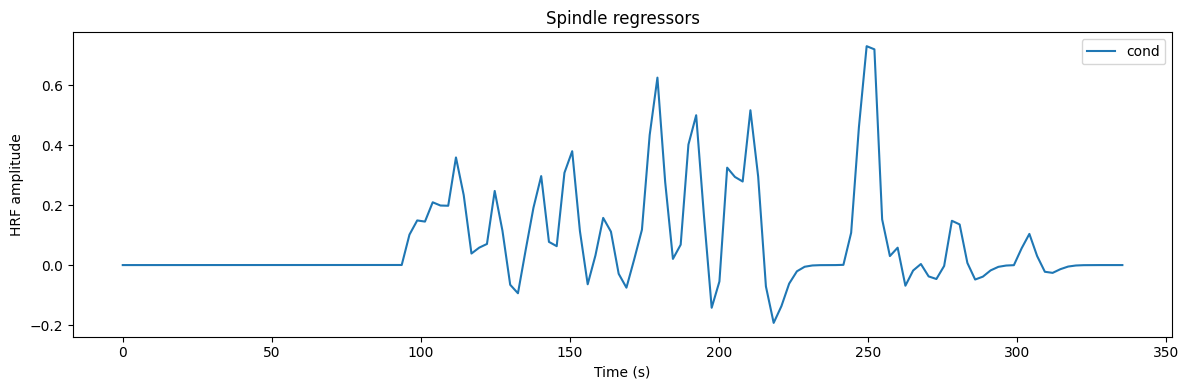

In [11]:
# If using dispersion and derivative
plt.figure(figsize=(12, 4))
for i in range(regressor.shape[1]):
    plt.plot(frame_times, regressor[:, i], label=names[i])
plt.xlabel('Time (s)')
plt.ylabel('HRF amplitude')
plt.title('Spindle regressors')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3389294/2135006245.py:13: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(design_matrix, ax=ax)


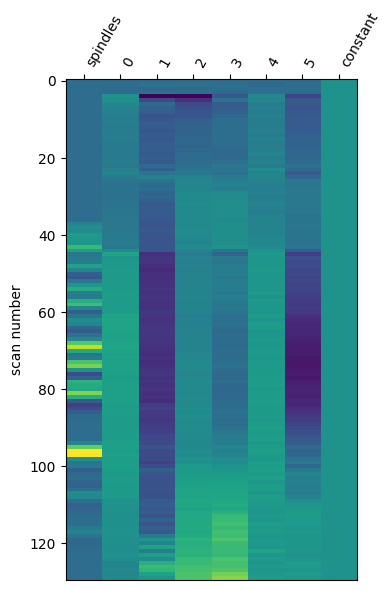

In [12]:
spindles['trial_type'] = 'spindles'

design_matrix = make_first_level_design_matrix(
    frame_times=frame_times,
    events=spindles,
    hrf_model='glover',
    drift_model=None,
    high_pass=1/128,
    add_regs=confounds
)

fig, ax = plt.subplots(figsize=(4, 6))
plot_design_matrix(design_matrix, ax=ax)
plt.tight_layout()
plt.show()

design_matrix.to_csv(f"{OUTPUT_DIR}/design_matrix.csv")
fig.savefig(f"{OUTPUT_DIR}/design_matrix.png", dpi=150, bbox_inches='tight')

In [13]:
# Check that there are no mismatched in nr of rows
img = nib.load(FUNC_IMG)
n_scans = img.shape[-1]

print("n_scans:", n_scans)
print("confounds shape:", confounds.shape)

n_scans: 130
confounds shape: (130, 6)


In [14]:
# Fit the GLM
first_level_model = FirstLevelModel(
    t_r=tr,
    hrf_model='glover',
    drift_model=None,
    # smoothing_fwhm=6.0,
    high_pass=1/128,
    standardize='zscore_sample',
    fir_delays=None,
    n_jobs=-1 # all CPU
)

first_level_model = first_level_model.fit(
    run_imgs=FUNC_IMG,
    events=spindles,
    confounds=confounds
)

In [15]:
print(design_matrix.columns.tolist())

['spindles', 0, 1, 2, 3, 4, 5, 'constant']


In [16]:
# Compute Z-stat maps
z_map_spin = first_level_model.compute_contrast('spindles', output_type='z_score')

z_map_spin_file = os.path.join(OUTPUT_DIR, f"z-{presmooth_file}.nii.gz")
z_map_spin.to_filename(z_map_spin_file)
print(f"Z-maps saved: {z_map_spin_file}")

Z-maps saved: /data/Annie/PROJECTS/RM_sleep2024/derivatives/sub-AY/stats/z-reg_scRun_BOLD_sub-AY_mcf_unwarp.nii.gz



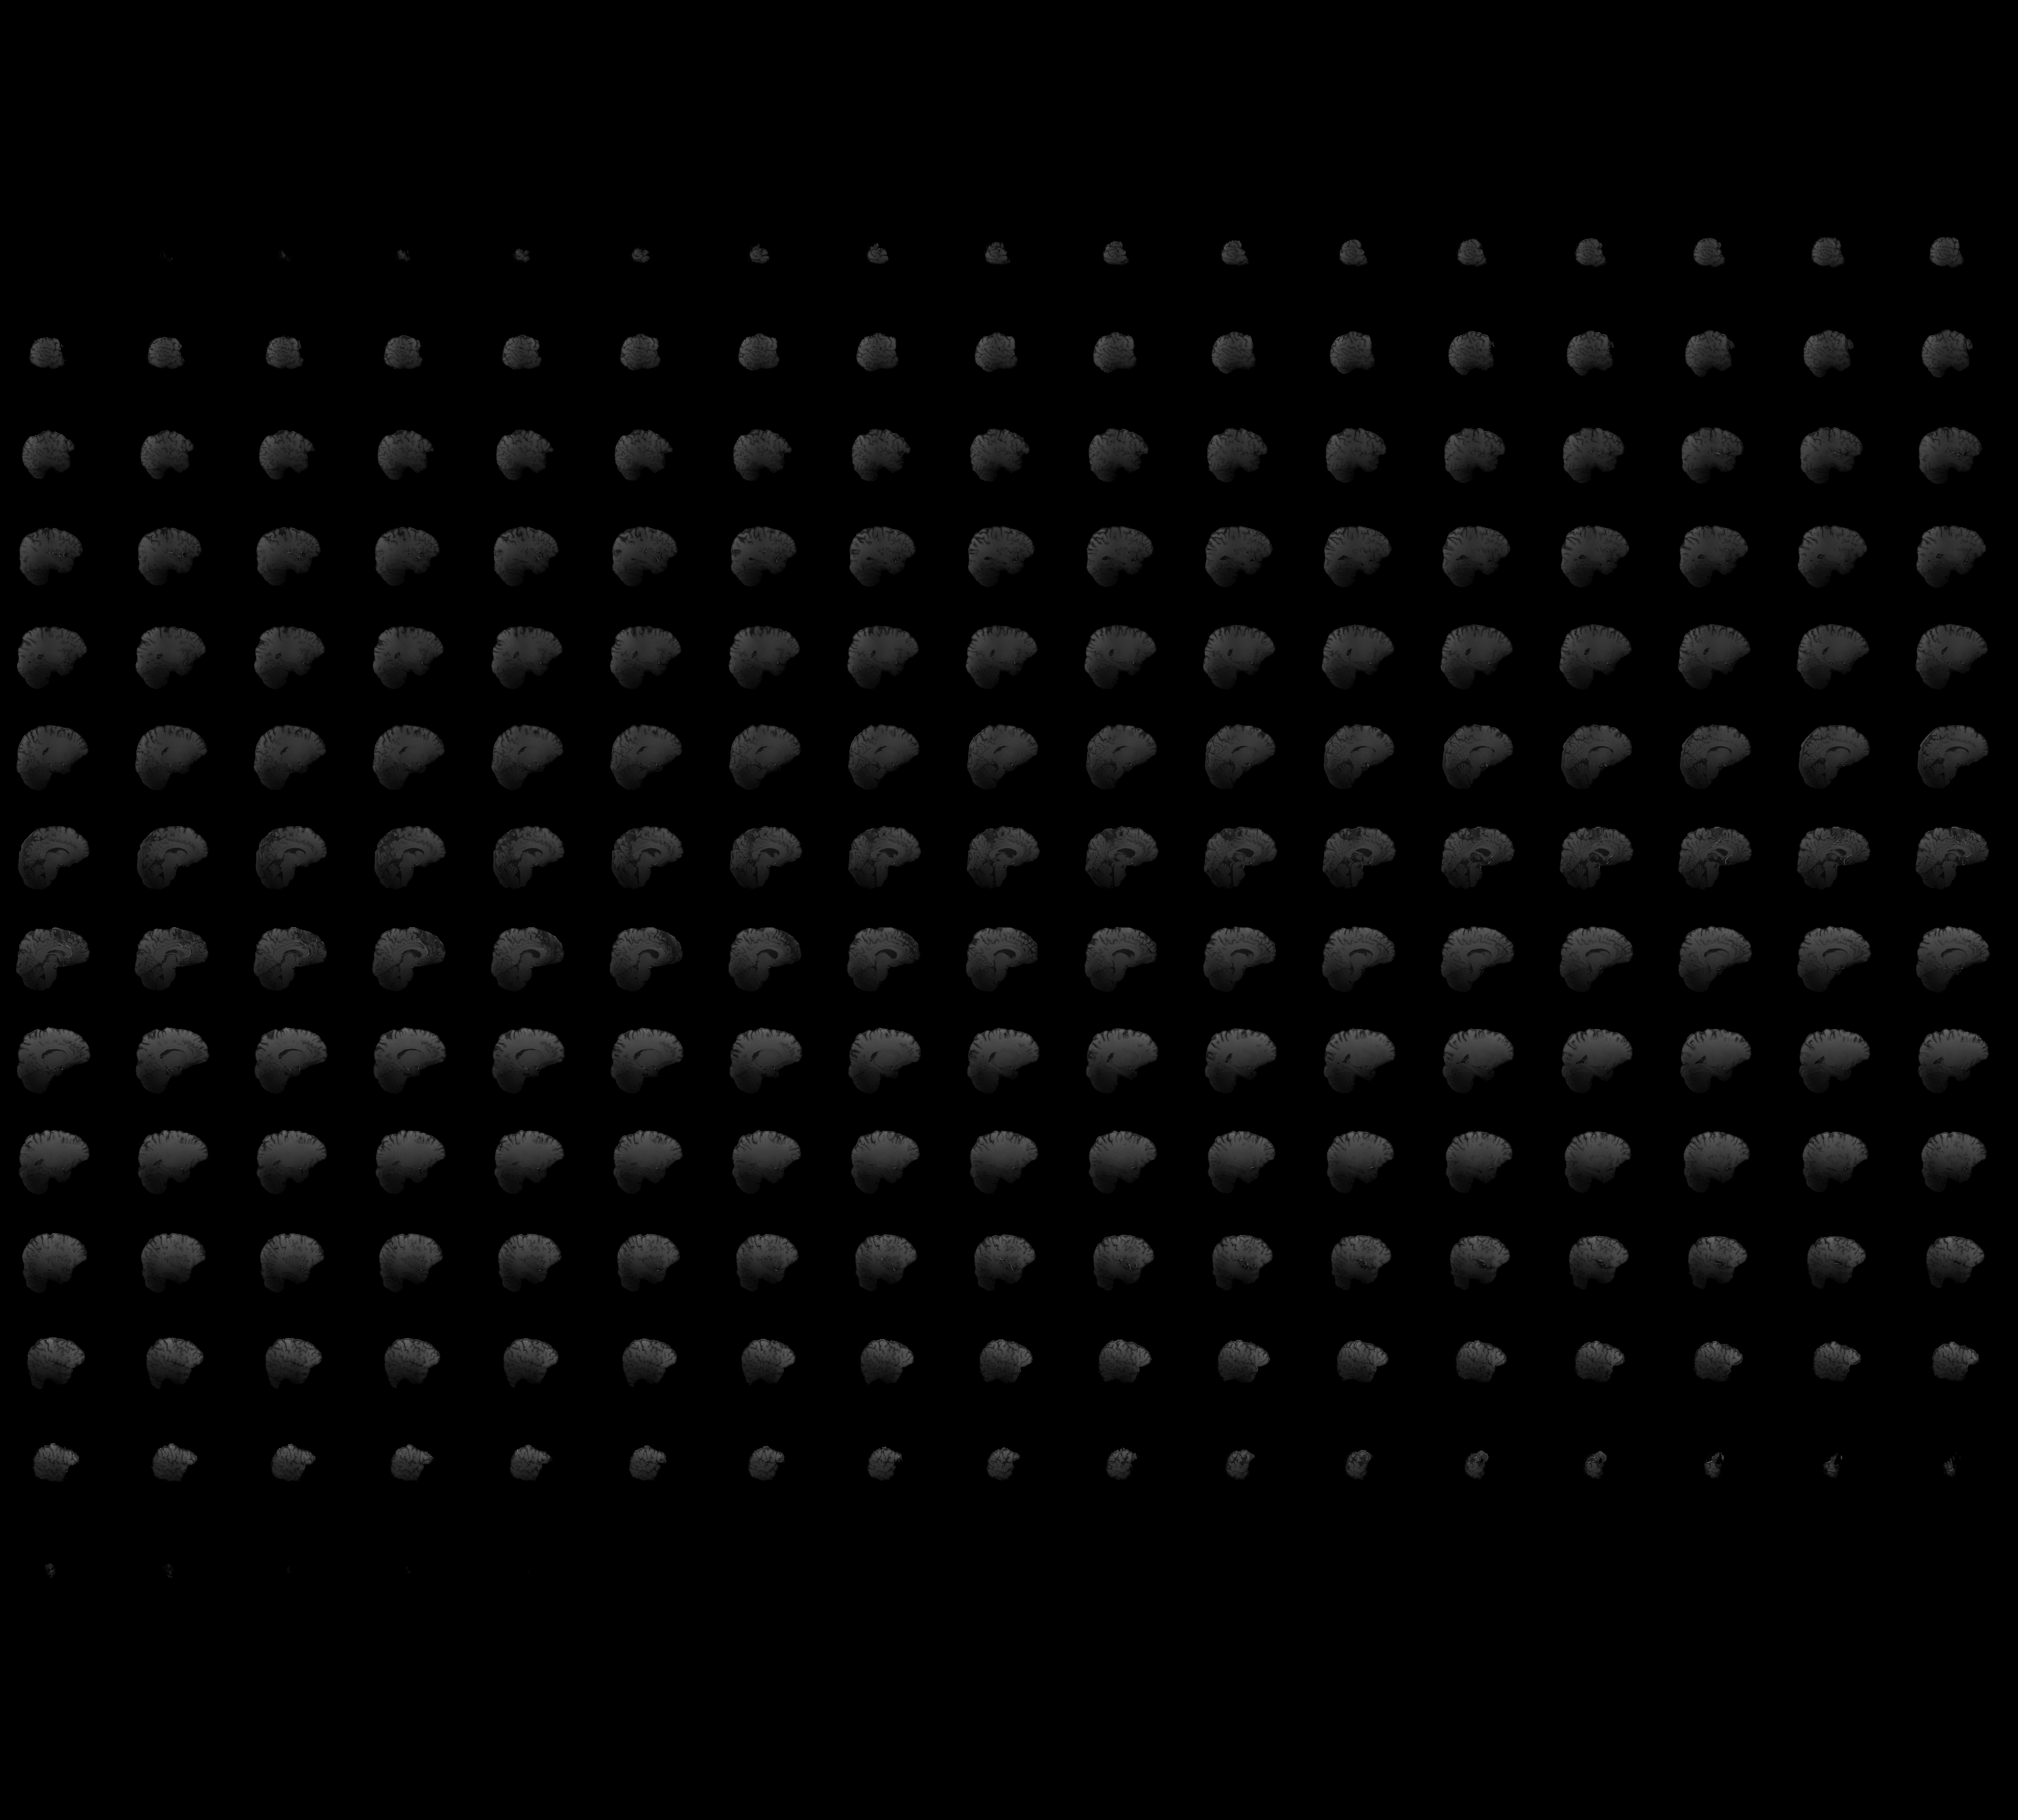
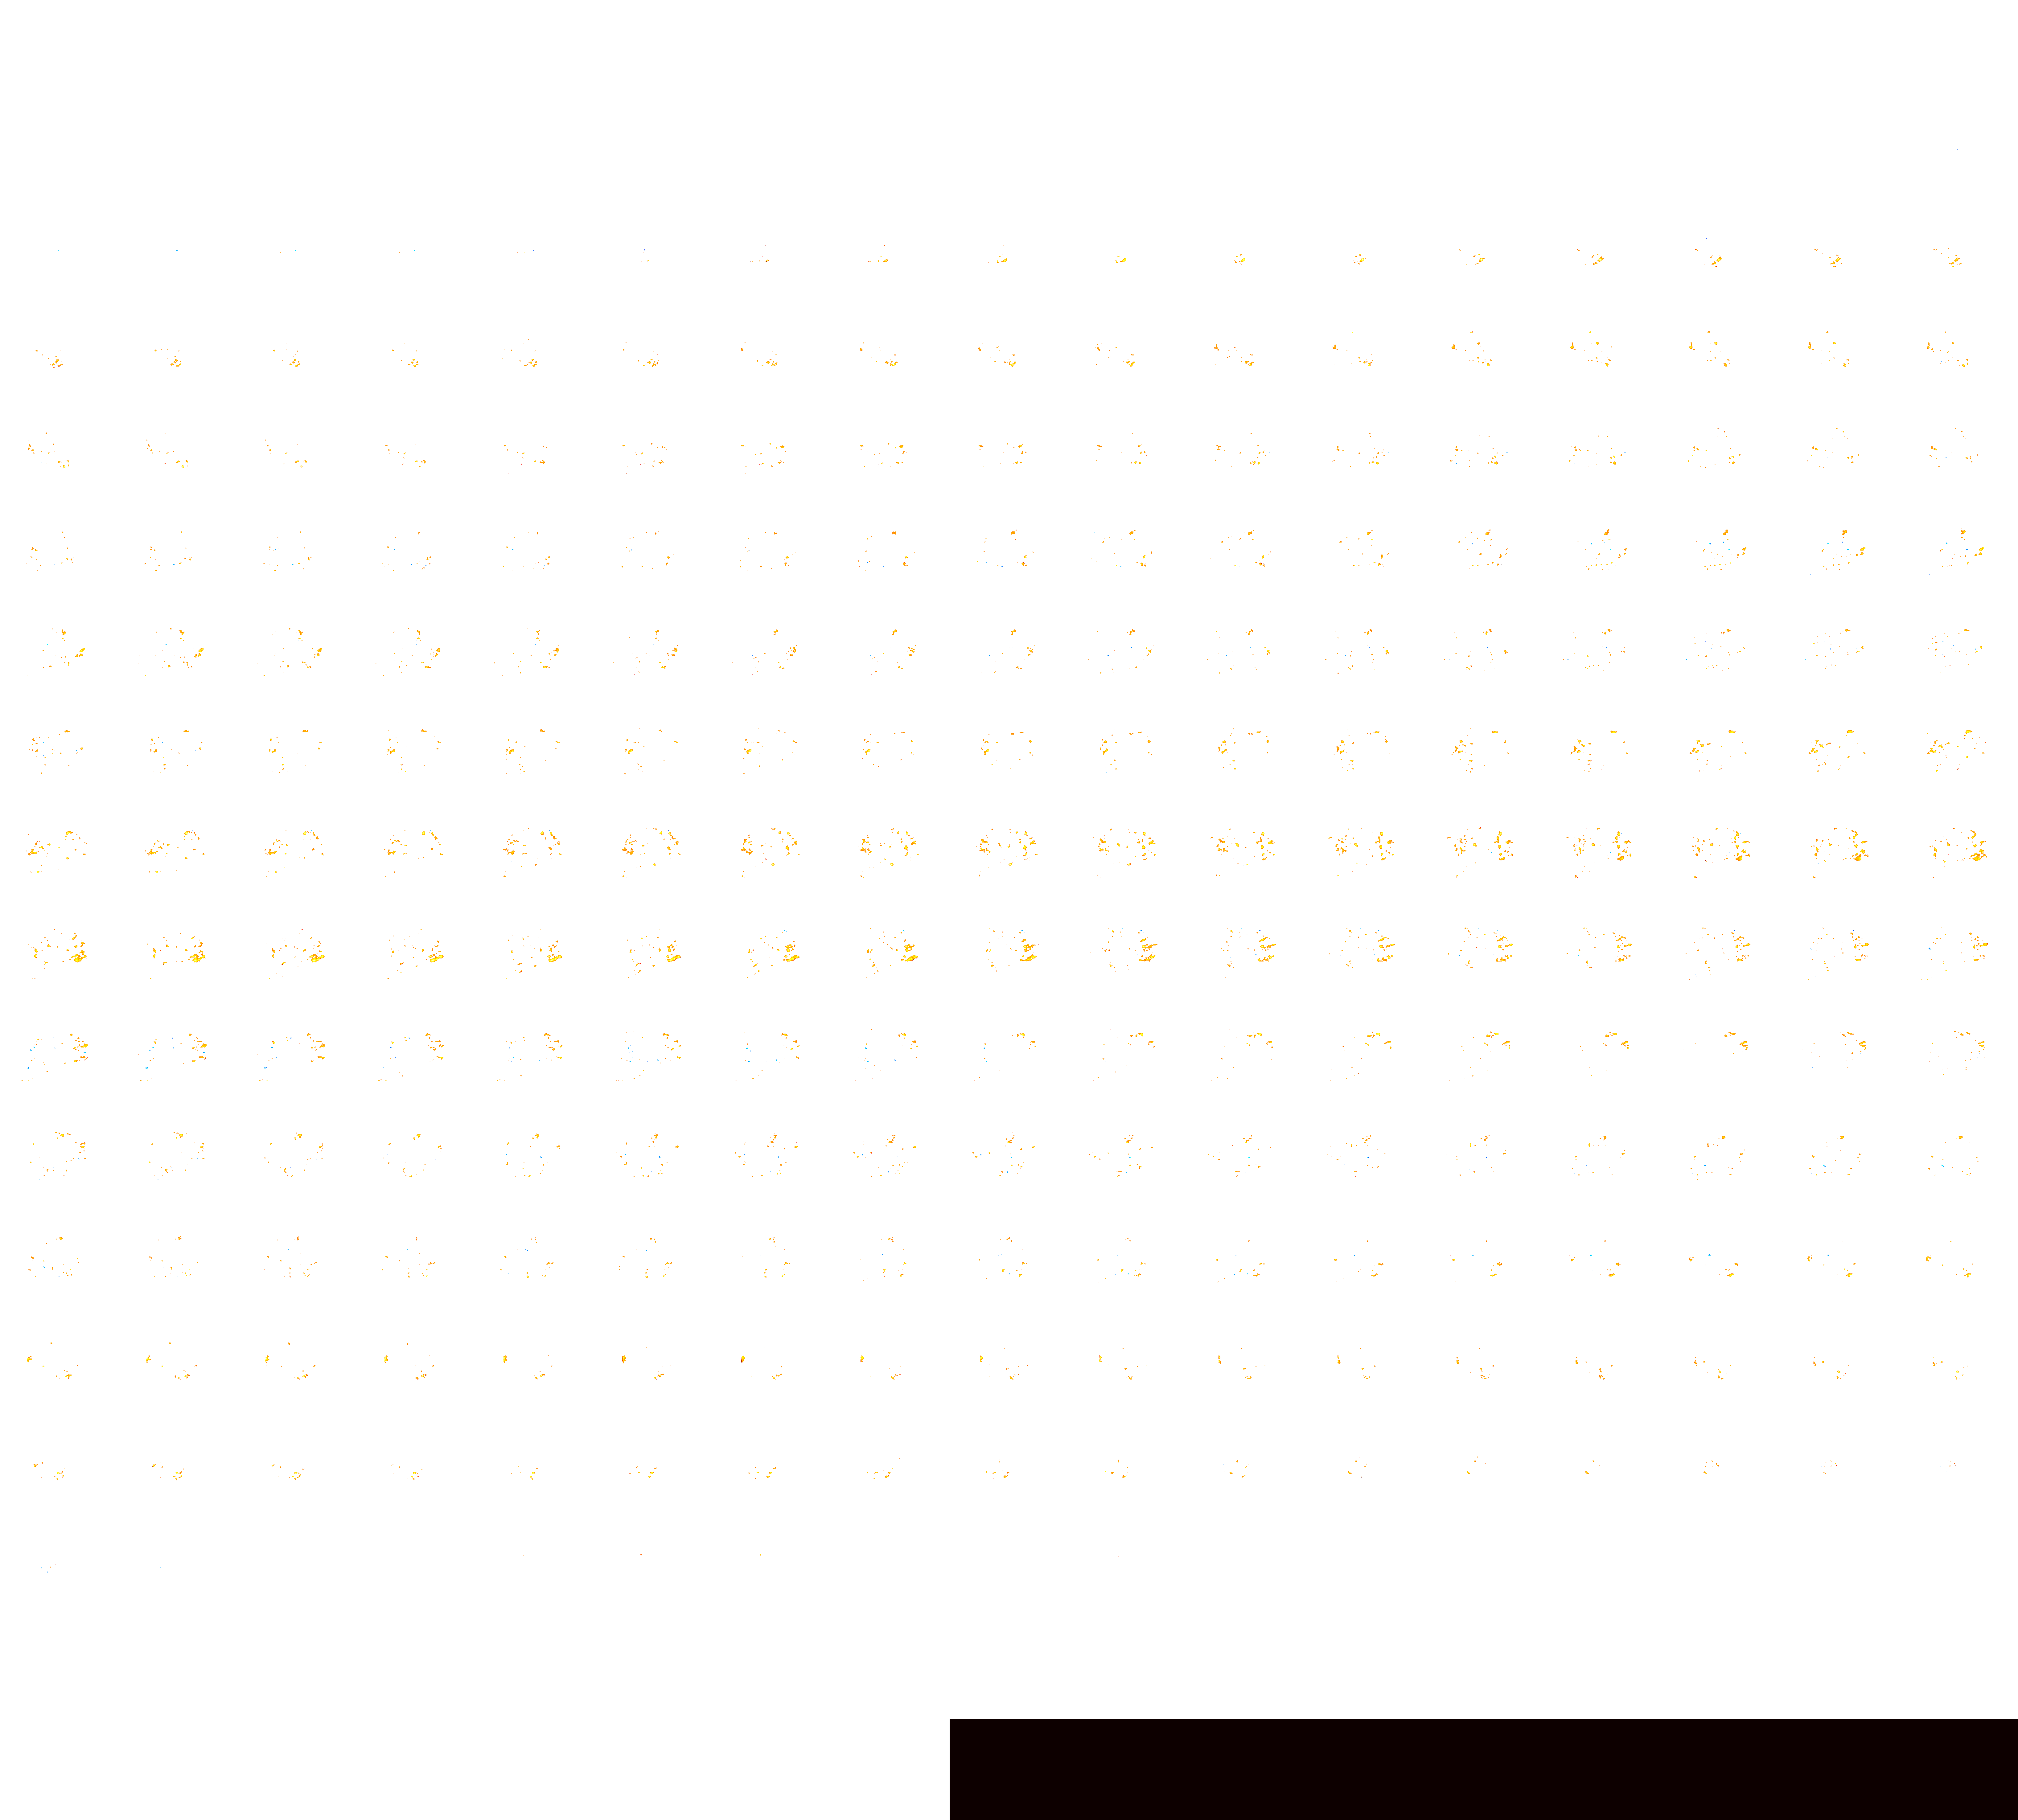

In [17]:
view1 = plotting.view_img(
    z_map_spin_file, anat,
    threshold=2.5, 
    opacity=0.9, 
    black_bg=True, 
    title='z-stat spindles'
    )

display(view1)
del view1